# Plot changes in thrombolysis rate by site

Use TASC-1 site data from a table (source?) and TASC-2 site data read off a grainy image (source?).

## Code setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.ticker as ticker  # for tick locations

## Load data

In [2]:
df_tasc1 = pd.read_csv('tasc1_table.csv')

df_tasc1

,site,left,right
0,1,10.0,14.0
1,2,8.0,12.0
2,3,8.5,18.8
3,4,8.0,15.0
4,5,8.0,10.0
5,6,9.6,14.0


In [3]:
df_tasc2 = pd.read_csv('tasc2_ruler_readings.csv')

df_tasc2

,site,left,right
0,1,9.5,20.5
1,2,9.3,22.4
2,3,10.0,14.4
3,4,8.5,21.9
4,5,14.0,21.3
5,6,10.4,16.0
6,7,14.9,14.9
7,8,13.0,14.7
8,9,8.9,10.2
9,10,9.0,14.4


## Create plot

In [4]:
plt.rcParams.update({'font.size': 14})

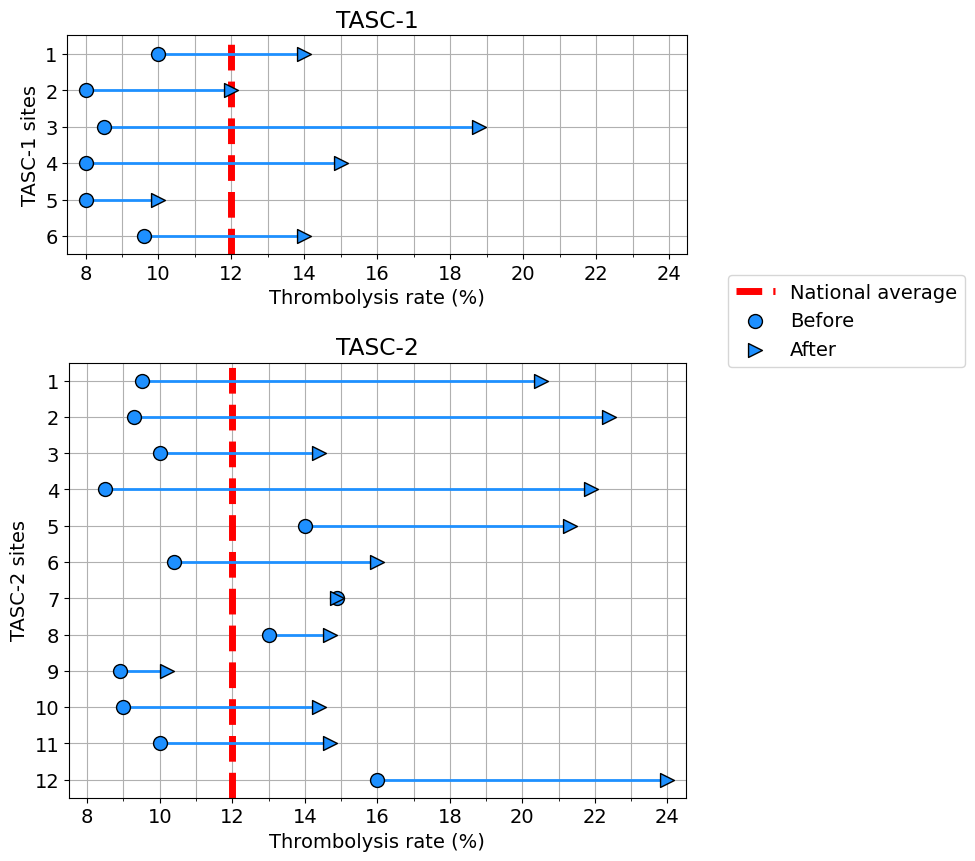

In [5]:
h = (len(df_tasc1) + 1) / (len(df_tasc2) + 1)

fig, axs = plt.subplots(2, figsize=(8, 10), gridspec_kw={'hspace': 0.3, 'height_ratios': [h, 1]})

ax_tasc1 = axs[0]
ax_tasc2 = axs[1]

draw_leg = True
marker_kwargs = dict(color='DodgerBlue', edgecolor='k', zorder=5, s=100)
for (df, ax) in [(df_tasc1, ax_tasc1), (df_tasc2, ax_tasc2)]:
    # Thrombolysis rate:
    ax.axvline(12, color='r', linestyle='--', label='National average', lw=5)
    # Connecting lines:
    ax.plot(df[['left', 'right']].transpose(), df[['site', 'site']].transpose(), color='DodgerBlue', lw=2)
    # Markers:
    ax.scatter(df['left'], df['site'], marker='o', **marker_kwargs, label='Before')
    ax.scatter(df['right'], df['site'], marker='>', **marker_kwargs, label='After')
    # Axis labels:
    ax.set_xlabel('Thrombolysis rate (%)')
    ax.set_yticks(df['site'])
    # X-axis:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2, offset=0.0))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1, offset=0.0))
    ax.set_xlim(7.5, 24.5)
    # Y-axis:
    ax.invert_yaxis()
    ax.set_ylim(df['site'].max() + 0.5, df['site'].min() - 0.5)
    # Axis size:
    ax.grid(which='both')
    ax.set_aspect('equal')
    if draw_leg:
        ax.legend(loc='upper left', bbox_to_anchor=[1.05, -0.05])
        draw_leg = False

ax_tasc1.set_title('TASC-1')
ax_tasc2.set_title('TASC-2')
ax_tasc1.set_ylabel('TASC-1 sites')
ax_tasc2.set_ylabel('TASC-2 sites')

plt.savefig('tasc1_tasc2_thrombolysis_rate_changes.png', bbox_inches='tight')
plt.show()